# Football Market Intelligence — Descriptive Analytics

**Phase 2: Market Structure and Behavior Analysis**

This notebook answers the following questions about the EPL Over/Under 2.5 Goals market, using 5 seasons of data (2019/20 – 2023/24):

1. **Market overview** — What are the base rates? How do goals and results distribute?
2. **Bookmaker margins** — How tight is the market? Sharp vs recreational gap?
3. **Pricing calibration** — Do implied probabilities actually reflect outcome rates?
4. **Team tendencies** — Which teams are systematically high/low-scoring?
5. **Odds distributions** — What does the pricing landscape look like?
6. **Market consensus** — Where do sharp and recreational books disagree?
7. **Market efficiency** — Is there structure the model can exploit?

---
> All analysis uses pre-match data only. No post-match statistics enter any feature or computation.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.analysis.descriptive import (
    season_summary,
    monthly_over25_rate,
    goals_distribution,
    result_distribution,
    bookmaker_margin_by_season,
    implied_prob_summary,
    sharp_vs_recreational_margin,
    calibration_data,
    overall_calibration_metrics,
    team_over25_rates,
    team_season_over25,
    top_bottom_teams,
    odds_distribution_by_bookmaker,
    odds_by_season,
    bookmaker_prob_divergence,
    high_divergence_matches,
    pinnacle_efficiency_check,
)

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.05)
PALETTE   = sns.color_palette('tab10')
SHARP_COL = PALETTE[0]   # blue  — Pinnacle
REC_COL   = PALETTE[1]   # orange — Bet365
NEUTRAL   = PALETTE[7]   # grey

FIG_W, FIG_H = 12, 5

print('Setup complete.')

Setup complete.


---
## 1. Market Overview

In [2]:
ss = season_summary()
print('=== Season Summary ===')
print(ss.to_string(index=False))

=== Season Summary ===
 season  matches  over25_n  over25_rate  avg_goals  avg_goals_home  avg_goals_away
2019/20      380     198.0       0.5211      2.721           1.516           1.205
2020/21      380     190.0       0.5000      2.695           1.353           1.342
2021/22      380     205.0       0.5395      2.818           1.513           1.305
2022/23      380     200.0       0.5263      2.853           1.634           1.218
2023/24      380     246.0       0.6474      3.279           1.800           1.479


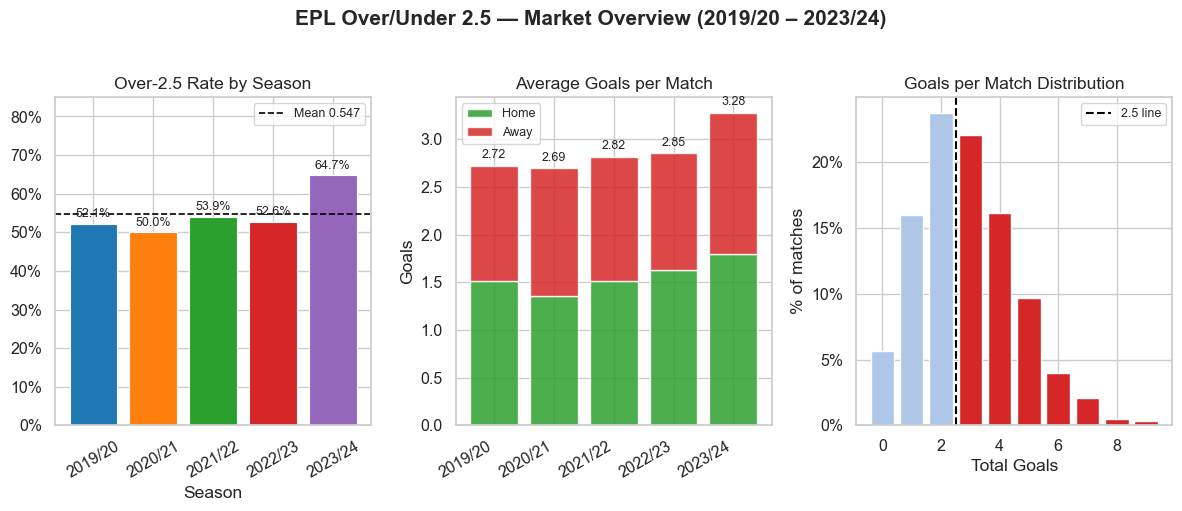

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(FIG_W, FIG_H))

# ── Panel 1: Over-2.5 rate per season ─────────────────────────────────────
ax = axes[0]
bars = ax.bar(ss['season'], ss['over25_rate'], color=PALETTE[:len(ss)], edgecolor='white', linewidth=0.8)
ax.axhline(ss['over25_rate'].mean(), color='black', ls='--', lw=1.2, label=f"Mean {ss['over25_rate'].mean():.3f}")
ax.set_ylim(0, 0.85)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
for bar, val in zip(bars, ss['over25_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.1%}",
            ha='center', va='bottom', fontsize=9)
ax.set_title('Over-2.5 Rate by Season')
ax.set_xlabel('Season')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9)

# ── Panel 2: Average goals per season ─────────────────────────────────────
ax = axes[1]
x = range(len(ss))
ax.bar(x, ss['avg_goals_home'], label='Home', color=PALETTE[2], alpha=0.85)
ax.bar(x, ss['avg_goals_away'], bottom=ss['avg_goals_home'], label='Away', color=PALETTE[3], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(ss['season'], rotation=30, ha='right')
ax.set_title('Average Goals per Match')
ax.set_ylabel('Goals')
ax.legend(fontsize=9)
for i, row in ss.iterrows():
    ax.text(i, row['avg_goals'] + 0.05, f"{row['avg_goals']:.2f}",
            ha='center', va='bottom', fontsize=9)

# ── Panel 3: Goals distribution ────────────────────────────────────────────
ax = axes[2]
gd = goals_distribution()
colors = ['#d62728' if g > 2 else '#aec7e8' for g in gd['total_goals']]
ax.bar(gd['total_goals'], gd['pct'], color=colors, edgecolor='white')
ax.axvline(2.5, color='black', ls='--', lw=1.5, label='2.5 line')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Goals per Match Distribution')
ax.set_xlabel('Total Goals')
ax.set_ylabel('% of matches')
ax.legend(fontsize=9)

fig.suptitle('EPL Over/Under 2.5 — Market Overview (2019/20 – 2023/24)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/01_market_overview.png', dpi=150, bbox_inches='tight')
plt.show()

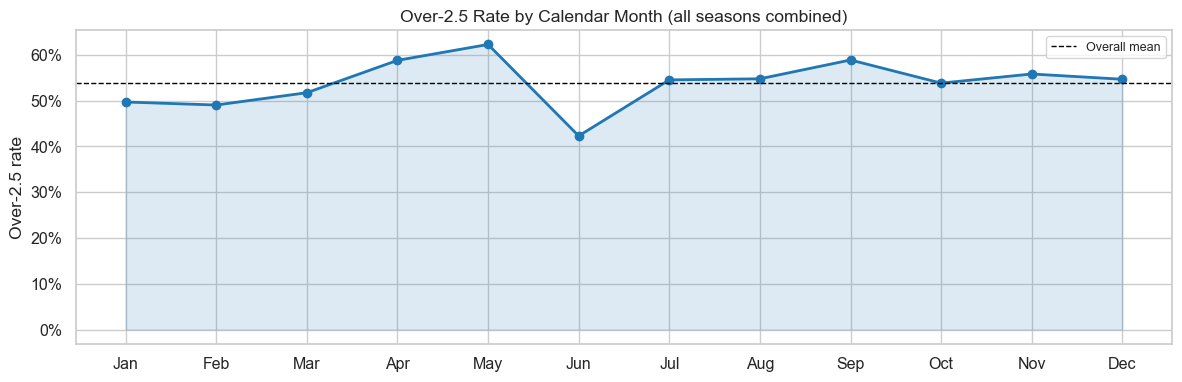

In [4]:
# Seasonality: over-2.5 rate by month
mo = monthly_over25_rate()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
mo['month_name'] = mo['month'].apply(lambda x: month_names[int(x)-1])

fig, ax = plt.subplots(figsize=(FIG_W, 4))
ax.plot(mo['month'], mo['over25_rate'], marker='o', color=SHARP_COL, lw=2)
ax.fill_between(mo['month'], mo['over25_rate'], alpha=0.15, color=SHARP_COL)
ax.axhline(mo['over25_rate'].mean(), color='black', ls='--', lw=1, label='Overall mean')
ax.set_xticks(mo['month'])
ax.set_xticklabels(mo['month_name'])
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Over-2.5 Rate by Calendar Month (all seasons combined)')
ax.set_ylabel('Over-2.5 rate')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../reports/figures/01b_monthly_over25.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Bookmaker Margin Analysis

Bookmaker margin (overround) is the structural tax built into prices.  
A bettor paying a higher margin needs a larger edge to profit.  
Pinnacle (sharp) vs Bet365 (recreational) shows the market structure clearly.

In [5]:
margins = bookmaker_margin_by_season()
print('=== Bookmaker Margin by Season (%) ===')
print(margins[['season','bookmaker','n','avg_margin_pct','std_margin_pct']].to_string(index=False))

=== Bookmaker Margin by Season (%) ===
 season      bookmaker   n  avg_margin_pct  std_margin_pct
2019/20 Market Maximum 380           0.897           1.481
2019/20       Pinnacle 380           2.595           0.333
2019/20 Market Average 380           4.942           0.307
2019/20         Bet365 380           5.491           0.370
2020/21 Market Maximum 380           0.693           0.727
2020/21       Pinnacle 380           2.866           0.525
2020/21 Market Average 380           4.845           0.249
2020/21         Bet365 380           5.415           0.655
2021/22 Market Maximum 380           0.752           0.752
2021/22       Pinnacle 380           3.003           0.501
2021/22 Market Average 380           4.577           0.336
2021/22         Bet365 379           4.871           1.275
2022/23 Market Maximum 380           1.076           0.811
2022/23       Pinnacle 379           3.038           0.558
2022/23         Bet365 380           4.493           1.355
2022/23 Market Av

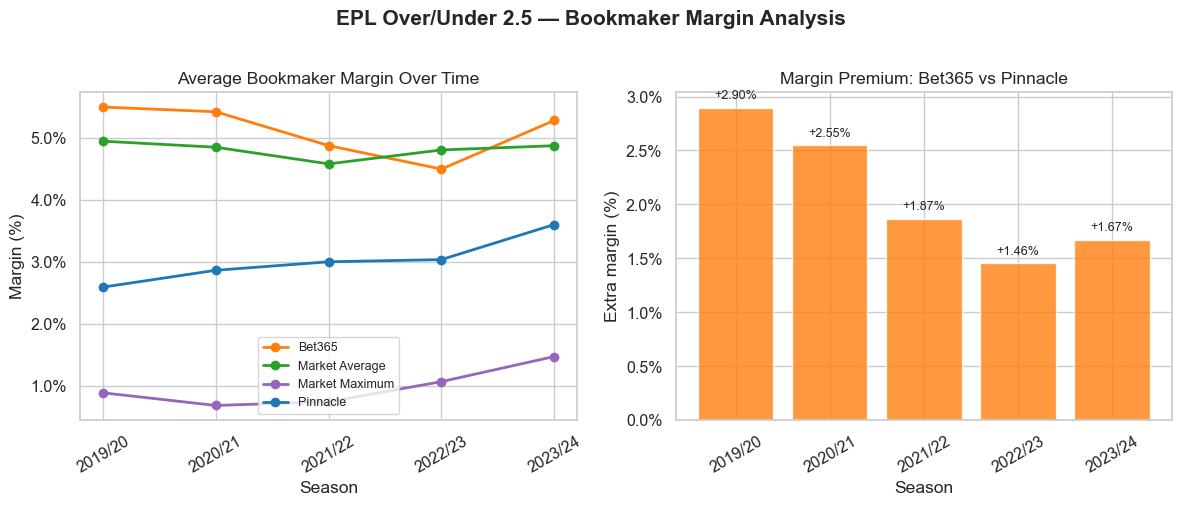

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 5))

# ── Panel 1: margin trend per bookmaker ────────────────────────────────────
ax = axes[0]
bk_palette = {'Pinnacle': SHARP_COL, 'Bet365': REC_COL,
               'Market Average': PALETTE[2], 'Market Maximum': PALETTE[4]}

for bk, grp in margins.groupby('bookmaker'):
    col = bk_palette.get(bk, NEUTRAL)
    ax.plot(grp['season'], grp['avg_margin_pct'], marker='o', lw=2, label=bk, color=col)

ax.set_title('Average Bookmaker Margin Over Time')
ax.set_ylabel('Margin (%)')
ax.set_xlabel('Season')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

# ── Panel 2: margin gap (B365 − Pinnacle) ─────────────────────────────────
ax = axes[1]
pin_m  = margins[margins['bookmaker'] == 'Pinnacle'][['season','avg_margin_pct']].set_index('season')
b365_m = margins[margins['bookmaker'] == 'Bet365'][['season','avg_margin_pct']].set_index('season')
gap = (b365_m['avg_margin_pct'] - pin_m['avg_margin_pct']).reset_index()
gap.columns = ['season','gap_pct']

ax.bar(gap['season'], gap['gap_pct'], color=REC_COL, alpha=0.8, edgecolor='white')
ax.set_title('Margin Premium: Bet365 vs Pinnacle')
ax.set_ylabel('Extra margin (%)')
ax.set_xlabel('Season')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
for i, (s, v) in enumerate(zip(gap['season'], gap['gap_pct'])):
    ax.text(i, v + 0.05, f"+{v:.2f}%", ha='center', va='bottom', fontsize=9)

fig.suptitle('EPL Over/Under 2.5 — Bookmaker Margin Analysis', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/02_margin_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Matches with both B365 and Pinnacle:  1890
Mean margin premium (B365 − PIN):     2.092%
Std  margin premium:                  1.177%
Mean prob disagreement (PIN − B365):  0.1503 pp
Std  prob disagreement:               1.9736 pp


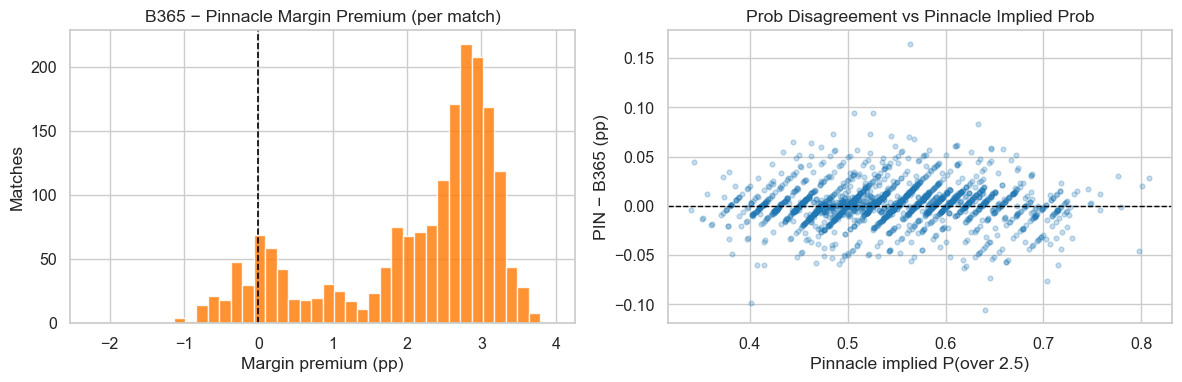

In [7]:
# Distribution of margin difference per match (B365 vs Pinnacle)
sr = sharp_vs_recreational_margin()
print(f"Matches with both B365 and Pinnacle:  {len(sr)}")
print(f"Mean margin premium (B365 − PIN):     {sr['margin_premium'].mean()*100:.3f}%")
print(f"Std  margin premium:                  {sr['margin_premium'].std()*100:.3f}%")
print(f"Mean prob disagreement (PIN − B365):  {sr['prob_disagreement'].mean()*100:.4f} pp")
print(f"Std  prob disagreement:               {sr['prob_disagreement'].std()*100:.4f} pp")

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 4))

ax = axes[0]
ax.hist(sr['margin_premium'] * 100, bins=40, color=REC_COL, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', ls='--', lw=1.2)
ax.set_title('B365 − Pinnacle Margin Premium (per match)')
ax.set_xlabel('Margin premium (pp)')
ax.set_ylabel('Matches')

ax = axes[1]
ax.scatter(sr['pin_prob_over'], sr['prob_disagreement'], alpha=0.25, s=12, color=SHARP_COL)
ax.axhline(0, color='black', ls='--', lw=1)
ax.set_title('Prob Disagreement vs Pinnacle Implied Prob')
ax.set_xlabel('Pinnacle implied P(over 2.5)')
ax.set_ylabel('PIN − B365 (pp)')

plt.tight_layout()
plt.savefig('../reports/figures/02b_margin_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Implied Probability Calibration

A bookmaker is **well calibrated** when their implied probabilities accurately reflect actual outcome frequencies.  

For Pinnacle (sharp market), good calibration is expected — it is a consensus of informed bettor opinion.  
For Bet365 (recreational), we expect a systematic overestimation bias (margin).

> **Interpretation:** Points above the diagonal = bookmaker underestimates probability (value for bettors).  
> Points below diagonal = bookmaker overestimates (negative expected value for bettors).

In [8]:
for bk in ['PIN', 'B365', 'AVG']:
    m = overall_calibration_metrics(bk)
    if not m:
        continue
    print(f"{m['bookmaker']:6s} | "
          f"N={m['n_matches']:4d} | "
          f"Mean implied prob: {m['mean_implied_prob']:.4f} | "
          f"Actual rate: {m['actual_over25_rate']:.4f} | "
          f"Bias: {m['avg_overround_bias']:+.4f} | "
          f"Brier: {m['brier_score']:.4f} | "
          f"Log-loss: {m['log_loss']:.4f}")

PIN    | N=1891 | Mean implied prob: 0.5422 | Actual rate: 0.5457 | Bias: -0.0035 | Brier: 0.2393 | Log-loss: 0.6714
B365   | N=1899 | Mean implied prob: 0.5417 | Actual rate: 0.5466 | Bias: -0.0049 | Brier: 0.2394 | Log-loss: 0.6716
AVG    | N=1900 | Mean implied prob: 0.5430 | Actual rate: 0.5468 | Bias: -0.0039 | Brier: 0.2391 | Log-loss: 0.6709


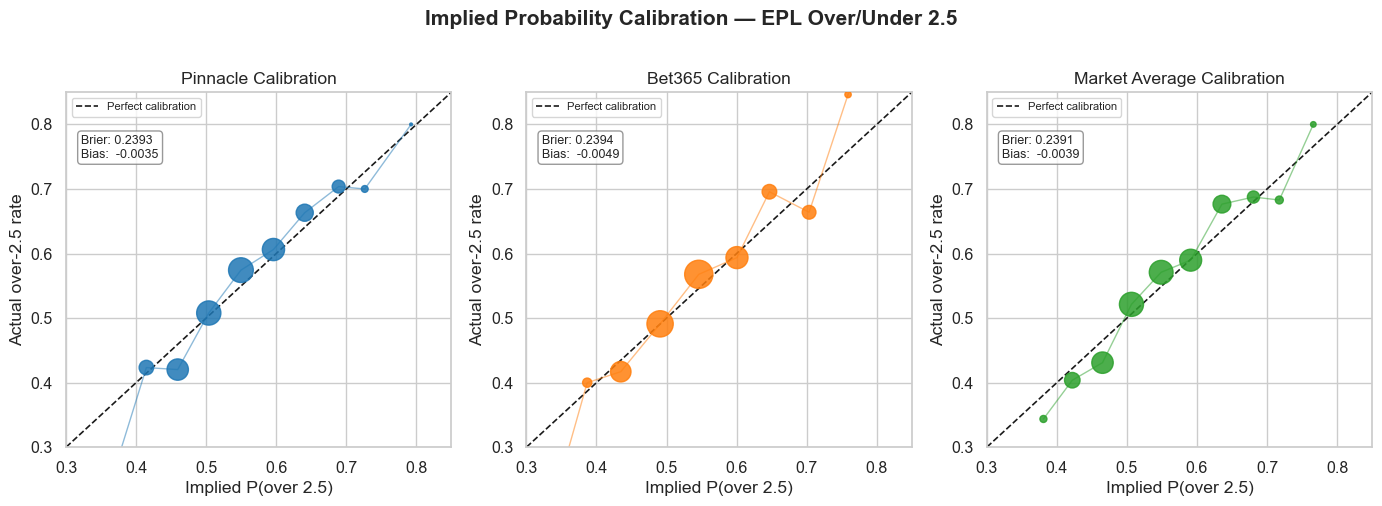

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(FIG_W + 2, 5))

bk_configs = [
    ('PIN',  'Pinnacle',       SHARP_COL),
    ('B365', 'Bet365',         REC_COL),
    ('AVG',  'Market Average', PALETTE[2]),
]

for ax, (code, name, color) in zip(axes, bk_configs):
    cal = calibration_data(bookmaker_short_code=code, n_bins=10)
    if cal.empty:
        ax.set_visible(False)
        continue

    ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Perfect calibration')
    sc = ax.scatter(
        cal['mean_implied_prob'], cal['actual_over25_rate'],
        s=cal['n'] * 0.8, c=color, alpha=0.85, zorder=3
    )
    ax.plot(cal['mean_implied_prob'], cal['actual_over25_rate'],
            color=color, alpha=0.5, lw=1)

    met = overall_calibration_metrics(code)
    annotation = (
        f"Brier: {met['brier_score']:.4f}\n"
        f"Bias:  {met['avg_overround_bias']:+.4f}"
    )
    ax.text(0.04, 0.88, annotation, transform=ax.transAxes,
            fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='grey', alpha=0.8))

    ax.set_title(f'{name} Calibration')
    ax.set_xlabel('Implied P(over 2.5)')
    ax.set_ylabel('Actual over-2.5 rate')
    ax.set_xlim(0.3, 0.85)
    ax.set_ylim(0.3, 0.85)
    ax.legend(fontsize=8)

fig.suptitle('Implied Probability Calibration — EPL Over/Under 2.5', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/03_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Team Tendency Analysis

Some teams are structurally more likely to feature in high-scoring matches.  
Understanding this is essential for both feature engineering and diagnostic analysis.

In [10]:
team_rates = team_over25_rates()
top8, bot8  = top_bottom_teams(n=8)

print("=== Top 8 Over-2.5 Teams ===")
print(top8[['team','home_over25_rate','away_over25_rate','combined_over25_rate']].to_string(index=False))
print()
print("=== Bottom 8 Over-2.5 Teams ===")
print(bot8[['team','home_over25_rate','away_over25_rate','combined_over25_rate']].to_string(index=False))

=== Top 8 Over-2.5 Teams ===
             team  home_over25_rate  away_over25_rate  combined_over25_rate
       Luton Town            0.6842            0.7368                0.7105
     Leeds United            0.5789            0.6842                0.6316
  Manchester City            0.6947            0.5684                0.6316
Tottenham Hotspur            0.6316            0.6211                0.6264
   Leicester City            0.6316            0.6053                0.6184
        Liverpool            0.5895            0.6421                0.6158
      Bournemouth            0.5614            0.6316                0.5965
          Arsenal            0.6842            0.5053                0.5948

=== Bottom 8 Over-2.5 Teams ===
                   team  home_over25_rate  away_over25_rate  combined_over25_rate
       Newcastle United            0.5263            0.5263                0.5263
               Brighton            0.4421            0.5579                0.5000
      No

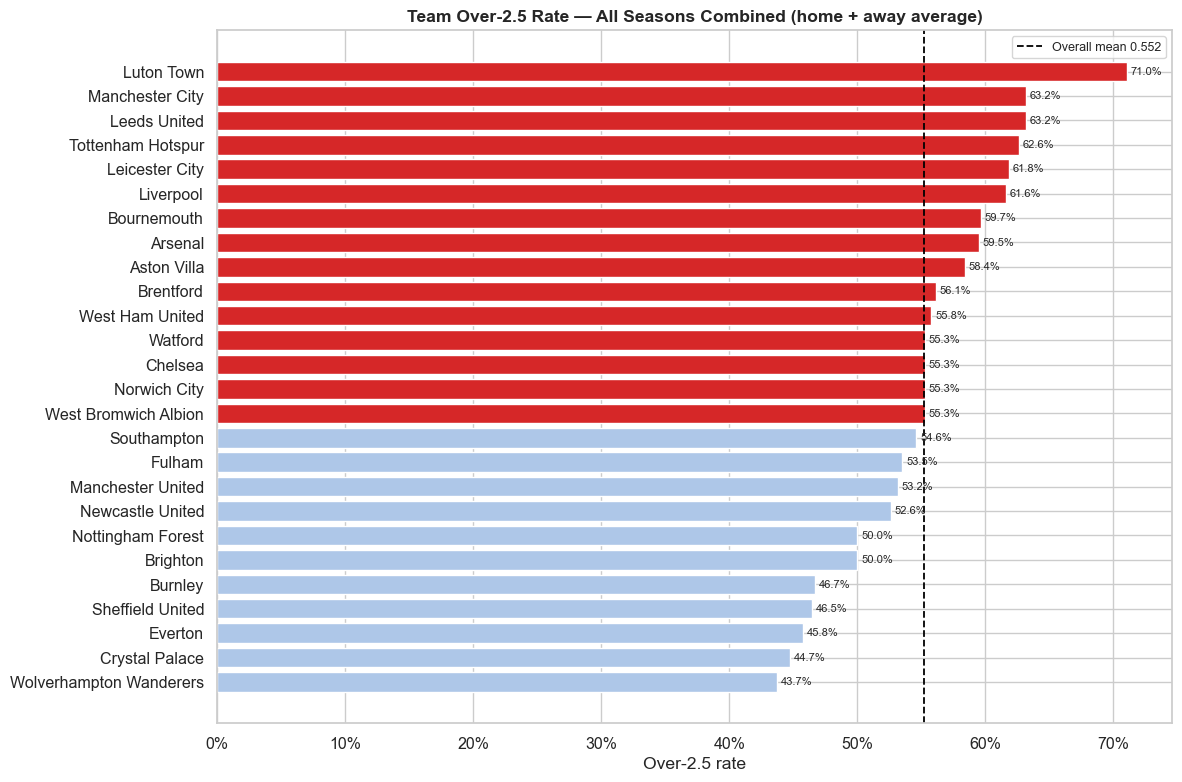

In [11]:
# Full team ranking
fig, ax = plt.subplots(figsize=(FIG_W, 8))

tr_sorted = team_rates.sort_values('combined_over25_rate', ascending=True)
overall_mean = tr_sorted['combined_over25_rate'].mean()

colors = ['#d62728' if v >= overall_mean else '#aec7e8' for v in tr_sorted['combined_over25_rate']]
ax.barh(tr_sorted['team'], tr_sorted['combined_over25_rate'], color=colors, edgecolor='white')
ax.axvline(overall_mean, color='black', ls='--', lw=1.3, label=f'Overall mean {overall_mean:.3f}')

for i, (v, h, a) in enumerate(zip(
    tr_sorted['combined_over25_rate'],
    tr_sorted['home_over25_rate'],
    tr_sorted['away_over25_rate']
)):
    ax.text(v + 0.003, i, f"{v:.1%}", va='center', fontsize=8)

ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Team Over-2.5 Rate — All Seasons Combined (home + away average)', fontweight='bold')
ax.set_xlabel('Over-2.5 rate')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../reports/figures/04_team_rankings.png', dpi=150, bbox_inches='tight')
plt.show()

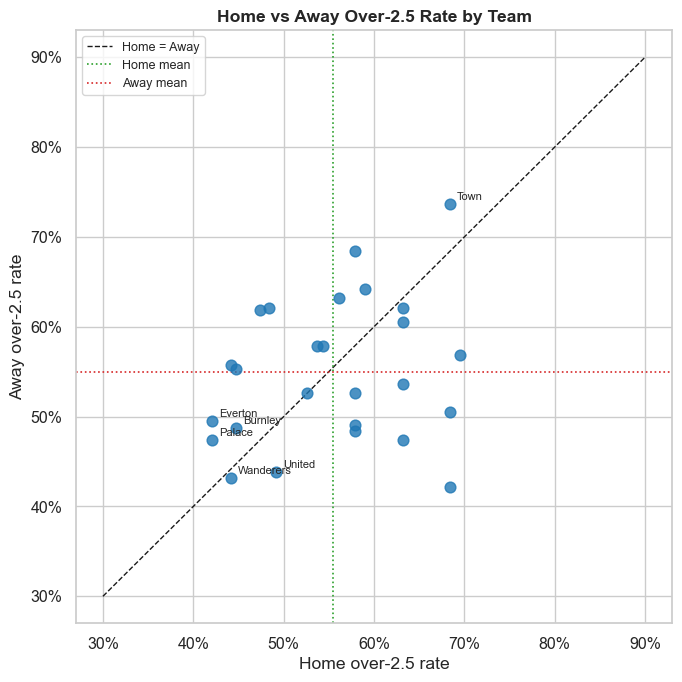

In [12]:
# Home vs Away over-2.5 rates (scatter — shows venue effect per team)
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(team_rates['home_over25_rate'], team_rates['away_over25_rate'],
           s=60, color=SHARP_COL, alpha=0.8, zorder=3)

# Labels for extreme teams
for _, row in team_rates.iterrows():
    if row['combined_over25_rate'] > 0.65 or row['combined_over25_rate'] < 0.48:
        ax.annotate(
            row['team'].split()[-1],
            (row['home_over25_rate'], row['away_over25_rate']),
            textcoords='offset points', xytext=(5, 3), fontsize=8
        )

ax.plot([0.3, 0.9], [0.3, 0.9], 'k--', lw=1, label='Home = Away')
ax.axvline(team_rates['home_over25_rate'].mean(), color=PALETTE[2], ls=':', lw=1.2, label='Home mean')
ax.axhline(team_rates['away_over25_rate'].mean(), color=PALETTE[3], ls=':', lw=1.2, label='Away mean')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Home vs Away Over-2.5 Rate by Team', fontweight='bold')
ax.set_xlabel('Home over-2.5 rate')
ax.set_ylabel('Away over-2.5 rate')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../reports/figures/04b_home_away_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

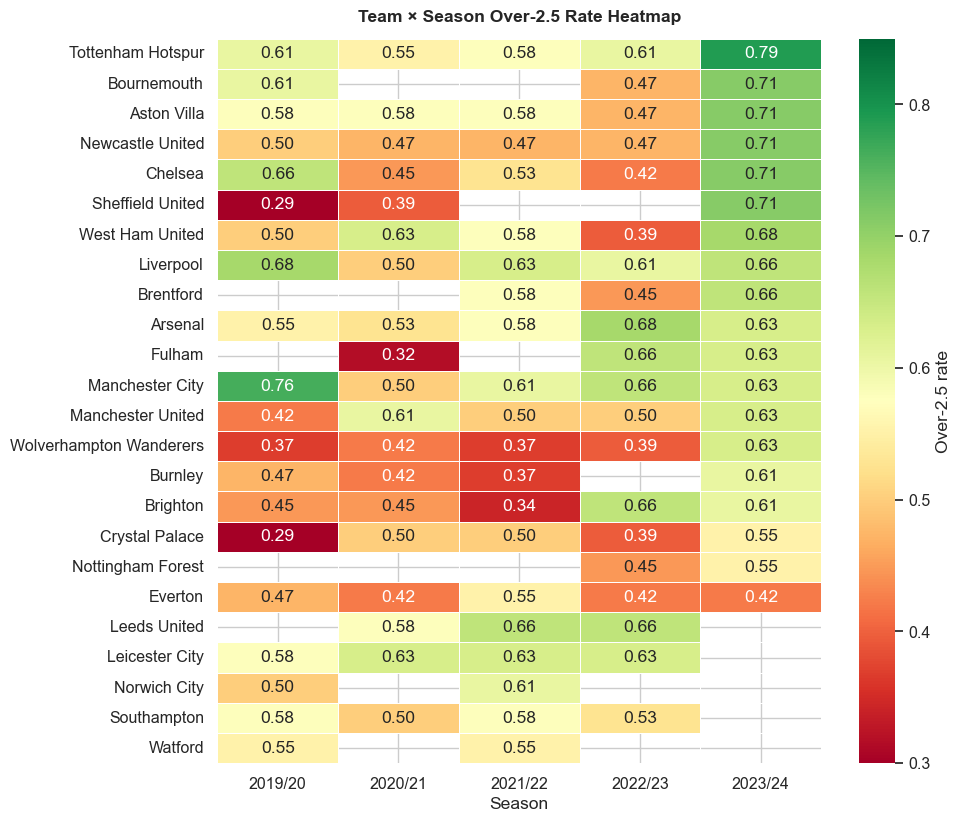

In [13]:
# Heatmap: team × season over-2.5 rate
ts = team_season_over25()

# Only teams with enough appearances
team_counts = ts.groupby('team')['matches'].sum()
active_teams = team_counts[team_counts >= 50].index

pivot = ts[ts['team'].isin(active_teams)].pivot_table(
    index='team', columns='season', values='over25_rate'
)
pivot = pivot.sort_values(pivot.columns[-1], ascending=False, na_position='last')

fig, ax = plt.subplots(figsize=(10, max(6, len(pivot) * 0.35)))
sns.heatmap(
    pivot, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=0.30, vmax=0.85,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Over-2.5 rate'},
    ax=ax
)
ax.set_title('Team × Season Over-2.5 Rate Heatmap', fontweight='bold', pad=12)
ax.set_xlabel('Season')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../reports/figures/04c_team_season_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Odds Distribution Analysis

In [14]:
print('=== Odds Distribution by Bookmaker ===')
print(odds_distribution_by_bookmaker().to_string(index=False))

=== Odds Distribution by Bookmaker ===
     bookmaker  min_odds  p10  p25  median  p75  p90  max_odds
        Bet365      1.12 1.44 1.57    1.75 2.00 2.20      3.20
Market Average      1.20 1.46 1.60    1.78 1.98 2.16      2.69
      Pinnacle      1.20 1.48 1.63    1.80 2.02 2.20      2.86
Market Maximum      1.22 1.50 1.66    1.84 2.06 2.25      2.88


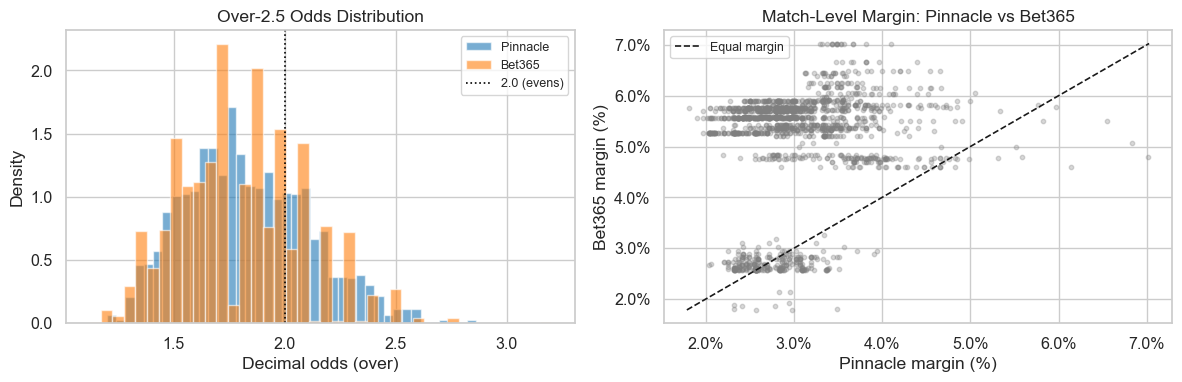


Pinnacle median odds over: 1.800
Bet365  median odds over : 1.750


In [15]:
from src.utils.db import run_query

# Fetch raw odds for histogram
raw_odds = run_query("""
    SELECT o.odds_over, bk.name AS bookmaker, bk.short_code
    FROM odds_snapshots o
    JOIN bookmakers bk ON o.bookmaker_id = bk.bookmaker_id
    WHERE o.odds_over IS NOT NULL
      AND bk.short_code IN ('PIN', 'B365')
""")

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 4))

# ── Panel 1: odds distribution overlay ────────────────────────────────────
ax = axes[0]
for bk_code, bk_name, col in [('PIN','Pinnacle',SHARP_COL), ('B365','Bet365',REC_COL)]:
    subset = raw_odds[raw_odds['short_code'] == bk_code]['odds_over']
    ax.hist(subset, bins=40, alpha=0.6, color=col, label=bk_name, edgecolor='white', density=True)
ax.axvline(2.0, color='black', ls=':', lw=1.2, label='2.0 (evens)')
ax.set_title('Over-2.5 Odds Distribution')
ax.set_xlabel('Decimal odds (over)')
ax.set_ylabel('Density')
ax.legend(fontsize=9)

# ── Panel 2: B365 vs PIN odds scatter ─────────────────────────────────────
ax = axes[1]
sr = sharp_vs_recreational_margin()
ax.scatter(
    sr['pin_margin'] * 100,
    sr['b365_margin'] * 100,
    alpha=0.3, s=10, color=NEUTRAL
)
rng = [min(sr['pin_margin'].min(), sr['b365_margin'].min()) * 100,
       max(sr['pin_margin'].max(), sr['b365_margin'].max()) * 100]
ax.plot(rng, rng, 'k--', lw=1.2, label='Equal margin')
ax.set_title('Match-Level Margin: Pinnacle vs Bet365')
ax.set_xlabel('Pinnacle margin (%)')
ax.set_ylabel('Bet365 margin (%)')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/05_odds_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPinnacle median odds over: {raw_odds[raw_odds['short_code']=='PIN']['odds_over'].median():.3f}")
print(f"Bet365  median odds over : {raw_odds[raw_odds['short_code']=='B365']['odds_over'].median():.3f}")

=== Pinnacle Over-2.5 Pricing by Season ===
 season  avg_odds_over  avg_odds_under  avg_implied_prob_over  avg_margin_pct   n
2019/20          1.841           2.234                 0.5438           2.595 380
2020/21          1.903           2.093                 0.5225           2.866 380
2021/22          1.885           2.108                 0.5259           3.003 380
2022/23          1.858           2.121                 0.5312           3.038 379
2023/24          1.669           2.425                 0.5886           3.602 372


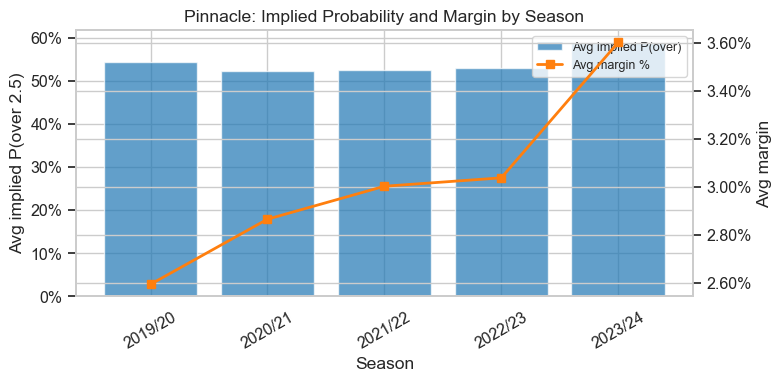

In [16]:
# How has Pinnacle's pricing shifted across seasons?
obs = odds_by_season()
print('=== Pinnacle Over-2.5 Pricing by Season ===')
print(obs.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax2 = ax.twinx()

ax.bar(obs['season'], obs['avg_implied_prob_over'], color=SHARP_COL, alpha=0.7, label='Avg implied P(over)')
ax2.plot(obs['season'], obs['avg_margin_pct'], color=REC_COL, marker='s', lw=2, label='Avg margin %')

ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
ax.set_title('Pinnacle: Implied Probability and Margin by Season')
ax.set_xlabel('Season')
ax.set_ylabel('Avg implied P(over 2.5)')
ax2.set_ylabel('Avg margin')
ax.tick_params(axis='x', rotation=30)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/05b_pinnacle_pricing_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Market Consensus — Where Do Sharp and Recreational Books Disagree?

In [17]:
divergence = bookmaker_prob_divergence()
print(f"Total PIN vs B365 match pairs: {len(divergence)}")
print(f"Mean absolute divergence:      {divergence['abs_divergence'].mean()*100:.3f} pp")
print(f"90th pct divergence:           {divergence['abs_divergence'].quantile(0.9)*100:.3f} pp")
print(f"Max divergence in dataset:     {divergence['abs_divergence'].max()*100:.3f} pp")

high_div = high_divergence_matches(min_divergence=0.05)
print(f"\nMatches with >5pp divergence:  {len(high_div)}")
print(f"Over-2.5 rate in those matches: {high_div['over_25'].mean():.3f}")
print(f"Over-2.5 rate in all matches:   {divergence['over_25'].mean():.3f}")

Total PIN vs B365 match pairs: 1890
Mean absolute divergence:      1.334 pp
90th pct divergence:           3.311 pp
Max divergence in dataset:     16.500 pp

Matches with >5pp divergence:  65
Over-2.5 rate in those matches: 0.569
Over-2.5 rate in all matches:   0.546


In [18]:
print('=== Top 15 Most Divergent Matches (PIN vs B365) ===')
print(
    high_div[['season','home_team','away_team','pinnacle_prob','bet365_prob',
               'abs_divergence','over_25','total_goals']]
    .head(15)
    .to_string(index=False)
)

=== Top 15 Most Divergent Matches (PIN vs B365) ===
 season               home_team               away_team  pinnacle_prob  bet365_prob  abs_divergence  over_25  total_goals
2020/21 Wolverhampton Wanderers       Manchester United         0.5635       0.3985          0.1650     True            3
2020/21               Liverpool          Crystal Palace         0.6399       0.7455          0.1056    False            2
2020/21                 Burnley        Newcastle United         0.4010       0.5000          0.0990     True            3
2019/20                 Chelsea Wolverhampton Wanderers         0.5064       0.4118          0.0946    False            2
2022/23                  Fulham                 Chelsea         0.5255       0.4315          0.0940     True            3
2020/21               Liverpool                 Burnley         0.6331       0.5497          0.0834    False            1
2022/23         Manchester City       Nottingham Forest         0.7038       0.7802          0

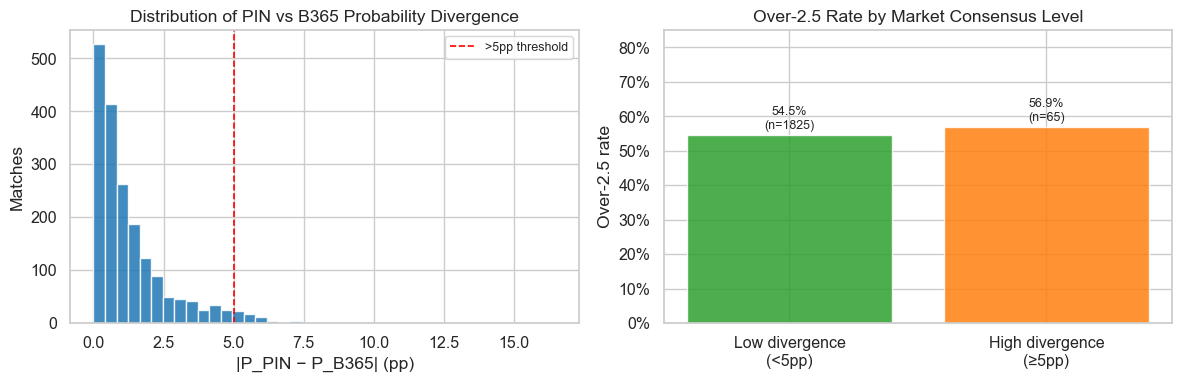

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 4))

# ── Panel 1: distribution of absolute divergence ──────────────────────────
ax = axes[0]
ax.hist(divergence['abs_divergence'] * 100, bins=40, color=SHARP_COL, edgecolor='white', alpha=0.85)
ax.axvline(5, color='red', ls='--', lw=1.2, label='>5pp threshold')
ax.set_title('Distribution of PIN vs B365 Probability Divergence')
ax.set_xlabel('|P_PIN − P_B365| (pp)')
ax.set_ylabel('Matches')
ax.legend(fontsize=9)

# ── Panel 2: actual rate in divergent vs non-divergent matches ────────────
ax = axes[1]
threshold = 0.05
low_div  = divergence[divergence['abs_divergence'] <  threshold]
high_div2 = divergence[divergence['abs_divergence'] >= threshold]

groups  = ['Low divergence\n(<5pp)', 'High divergence\n(≥5pp)']
rates   = [low_div['over_25'].mean(), high_div2['over_25'].mean()]
counts  = [len(low_div), len(high_div2)]
bar_cols = [PALETTE[2], PALETTE[1]]

bars = ax.bar(groups, rates, color=bar_cols, edgecolor='white', alpha=0.85)
for bar, r, c in zip(bars, rates, counts):
    ax.text(bar.get_x() + bar.get_width()/2, r + 0.01,
            f"{r:.1%}\n(n={c})", ha='center', va='bottom', fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Over-2.5 Rate by Market Consensus Level')
ax.set_ylabel('Over-2.5 rate')
ax.set_ylim(0, 0.85)

plt.tight_layout()
plt.savefig('../reports/figures/06_market_consensus.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Market Efficiency Check

If Pinnacle's market were perfectly efficient, a flat bet on all over-2.5 matches (at any implied probability level) would yield ROI ≈ −margin.

Any systematic deviation — where certain probability bands consistently over- or under-perform — is a signal of structural inefficiency.

> Note: with 1900 matches, individual decile cells have ~190 matches. Statistical uncertainty is material.  
> These findings are **descriptive hypotheses**, not confirmed edges.

In [20]:
eff = pinnacle_efficiency_check()
print('=== Market Efficiency by Probability Decile (Pinnacle) ===')
print(eff.to_string(index=False))

=== Market Efficiency by Probability Decile (Pinnacle) ===
 decile   n  mean_implied_prob  actual_over25_rate  avg_odds_over    edge  flat_roi
      0 190             0.4110              0.3895         2.3705 -0.0216   -0.0767
      1 202             0.4567              0.4010         2.1303 -0.0557   -0.1458
      2 180             0.4827              0.5111         2.0211  0.0284    0.0330
      3 185             0.5051              0.5135         1.9299  0.0084   -0.0089
      4 192             0.5284              0.5677         1.8421  0.0394    0.0458
      5 186             0.5491              0.5484         1.7687 -0.0008   -0.0301
      6 191             0.5732              0.5445         1.6921 -0.0286   -0.0787
      7 187             0.5984              0.6417         1.6220  0.0433    0.0409
      8 190             0.6310              0.6263         1.5321 -0.0046   -0.0404
      9 188             0.6903              0.7234         1.3964  0.0331    0.0101


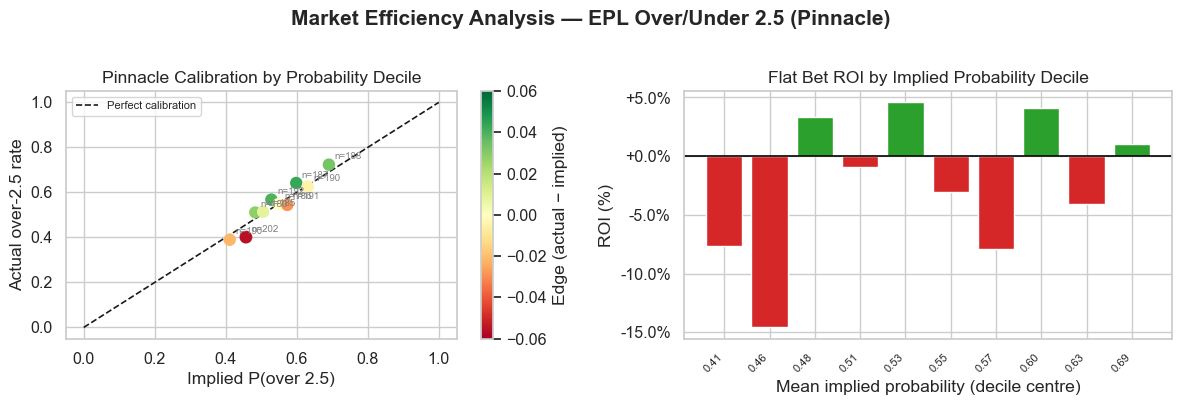

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 4))

# ── Panel 1: calibration deciles ──────────────────────────────────────────
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Perfect calibration')
scatter = ax.scatter(
    eff['mean_implied_prob'], eff['actual_over25_rate'],
    c=eff['edge'], cmap='RdYlGn', vmin=-0.06, vmax=0.06,
    s=eff['n'] / 3, zorder=3
)
for _, row in eff.iterrows():
    ax.annotate(
        f"n={int(row['n'])}",
        (row['mean_implied_prob'], row['actual_over25_rate']),
        textcoords='offset points', xytext=(4, 4), fontsize=7, color='grey'
    )
plt.colorbar(scatter, ax=ax, label='Edge (actual − implied)')
ax.set_title('Pinnacle Calibration by Probability Decile')
ax.set_xlabel('Implied P(over 2.5)')
ax.set_ylabel('Actual over-2.5 rate')
ax.legend(fontsize=8)

# ── Panel 2: flat ROI by decile ───────────────────────────────────────────
ax = axes[1]
bar_colors = ['#d62728' if r < 0 else '#2ca02c' for r in eff['flat_roi']]
ax.bar(range(len(eff)), eff['flat_roi'] * 100, color=bar_colors, edgecolor='white')
ax.axhline(0, color='black', lw=1.2)
ax.set_xticks(range(len(eff)))
ax.set_xticklabels([f"{p:.2f}" for p in eff['mean_implied_prob']], rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.1f%%'))
ax.set_title('Flat Bet ROI by Implied Probability Decile')
ax.set_xlabel('Mean implied probability (decile centre)')
ax.set_ylabel('ROI (%)')

plt.suptitle('Market Efficiency Analysis — EPL Over/Under 2.5 (Pinnacle)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/07_market_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Key Findings Summary

Run the cell below to print a structured summary of the key descriptive findings.

In [22]:
ss     = season_summary()
m_pin  = overall_calibration_metrics('PIN')
m_b365 = overall_calibration_metrics('B365')
top8, bot8 = top_bottom_teams(n=5)
div    = bookmaker_prob_divergence()
mg     = bookmaker_margin_by_season()

print("=" * 65)
print("FOOTBALL MARKET INTELLIGENCE — PHASE 2 KEY FINDINGS")
print("EPL Over/Under 2.5 Goals | 2019/20 – 2023/24")
print("=" * 65)

print("\n--- MARKET OVERVIEW ---")
for _, row in ss.iterrows():
    print(f"  {row['season']}: {row['over25_rate']:.1%} over-2.5  |  "
          f"avg goals {row['avg_goals']:.2f}")

print("\n--- BOOKMAKER MARGINS (avg % per season) ---")
for bk in ['Pinnacle', 'Bet365']:
    subset = mg[mg['bookmaker'] == bk]
    print(f"  {bk:20s}: "
          + "  ".join([f"{s} {v:.2f}%" for s, v in zip(subset['season'], subset['avg_margin_pct'])]))

print("\n--- CALIBRATION (Pinnacle vs Bet365) ---")
print(f"  Pinnacle | Brier score: {m_pin['brier_score']:.4f} | "
      f"Log-loss: {m_pin['log_loss']:.4f} | Bias: {m_pin['avg_overround_bias']:+.4f}")
print(f"  Bet365   | Brier score: {m_b365['brier_score']:.4f} | "
      f"Log-loss: {m_b365['log_loss']:.4f} | Bias: {m_b365['avg_overround_bias']:+.4f}")

print("\n--- TOP 5 HIGH-SCORING TEAMS ---")
for _, r in top8.iterrows():
    print(f"  {r['team']:30s}  combined over-2.5: {r['combined_over25_rate']:.1%}")

print("\n--- TOP 5 LOW-SCORING TEAMS ---")
for _, r in bot8.sort_values('combined_over25_rate').iterrows():
    print(f"  {r['team']:30s}  combined over-2.5: {r['combined_over25_rate']:.1%}")

print("\n--- MARKET CONSENSUS ---")
print(f"  Mean |PIN − B365| divergence: {div['abs_divergence'].mean()*100:.3f} pp")
print(f"  Matches with >5pp divergence: {(div['abs_divergence'] >= 0.05).sum()}")

print("\n--- KEY FINDING: 2023/24 ANOMALY ---")
for _, row in ss.iterrows():
    print(f"  {row['season']}: {row['over25_rate']:.3f} over-2.5 rate")
five_season_mean = ss['over25_rate'].mean()
print(f"\n  5-season mean:  {five_season_mean:.3f}")
print(f"  2023/24 delta:  {ss[ss['season']=='2023/24']['over25_rate'].values[0] - five_season_mean:+.3f}")
print("  → 2023/24 over-2.5 rate is a clear structural break from prior seasons.")
print("  → Diagnostic Phase 3 and feature engineering must account for this shift.")

print("\n" + "=" * 65)

FOOTBALL MARKET INTELLIGENCE — PHASE 2 KEY FINDINGS
EPL Over/Under 2.5 Goals | 2019/20 – 2023/24

--- MARKET OVERVIEW ---
  2019/20: 52.1% over-2.5  |  avg goals 2.72
  2020/21: 50.0% over-2.5  |  avg goals 2.69
  2021/22: 53.9% over-2.5  |  avg goals 2.82
  2022/23: 52.6% over-2.5  |  avg goals 2.85
  2023/24: 64.7% over-2.5  |  avg goals 3.28

--- BOOKMAKER MARGINS (avg % per season) ---
  Pinnacle            : 2019/20 2.60%  2020/21 2.87%  2021/22 3.00%  2022/23 3.04%  2023/24 3.60%
  Bet365              : 2019/20 5.49%  2020/21 5.42%  2021/22 4.87%  2022/23 4.49%  2023/24 5.28%

--- CALIBRATION (Pinnacle vs Bet365) ---
  Pinnacle | Brier score: 0.2393 | Log-loss: 0.6714 | Bias: -0.0035
  Bet365   | Brier score: 0.2394 | Log-loss: 0.6716 | Bias: -0.0049

--- TOP 5 HIGH-SCORING TEAMS ---
  Luton Town                      combined over-2.5: 71.0%
  Leeds United                    combined over-2.5: 63.2%
  Manchester City                 combined over-2.5: 63.2%
  Tottenham Hotspur   